## Project: 3: FRED API
### In this projectm, we will dig into different type of data obtained from the Fred APi which provides info from different indicators from the USA. e.g: Unemployment, Index Funds, GDP

In [124]:
# Step 1: Installing the fred API
# !pip install fredapi

### 1) Importing libraries to start working

In [2]:
# Importing libraries
import os 
from dotenv import load_dotenv
from fredapi import Fred # Fred API
import numpy as np # linear algebra
import pandas as pd # data processin

pd.set_option('display.max_columns',500)
pd.set_option('display.max_rows',500)

# Visual 
import matplotlib.pyplot as plt # Visual tool
import seaborn as sns # style tool
import plotly.express as px
sns.set_theme()

### 2) Starting Fred API and importing my key

In [3]:
# Upload all the variables from the file .env
load_dotenv()

# Read the Fred API key 
fred_key = os.getenv('FRED_API_KEY')

# Starting Fred
fred = Fred(api_key=fred_key)

### Task 1: Obtain data from the SP500 and make a plot

####  Step 1.1: Search for the data

In [4]:
sp_search = fred.search('S&P', order_by = 'popularity')
sp_search.loc[['SP500'],:]

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
SP500,SP500,2026-07-09,2026-07-09,S&P 500,2016-07-11,2026-07-08,"Daily, Close",D,Index,Index,Not Seasonally Adjusted,NSA,2026-07-08 19:03:23-05:00,90,The observations for the S&P 500 represent the...


####  Step 1.2: Pull the data from the SP500

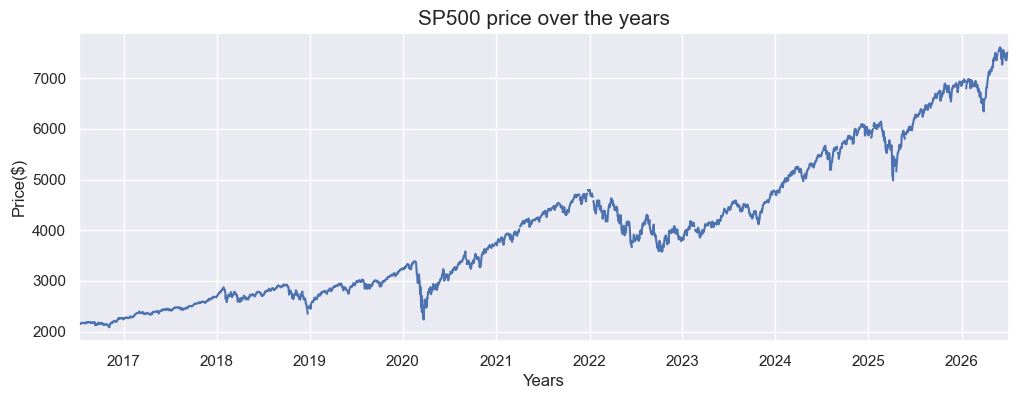

In [5]:
# Pullin the raw data, We have the datetime as index and the price of the index as values
fred.get_series('SP500')

fred.get_series('SP500').plot(figsize=(12,4))
plt.xlabel('Years')
plt.ylabel('Price($)')
plt.title('SP500 price over the years', fontdict={'fontsize':'15'})
plt.show()

### Task 2: Obtain the GDP from the United States

In [6]:
fred.search("gdp").head()

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
GFDEGDQ188S,GFDEGDQ188S,2026-07-09,2026-07-09,Federal Debt: Total Public Debt as Percent of ...,1966-01-01,2026-01-01,Quarterly,Q,Percent of GDP,% of GDP,Seasonally Adjusted,SA,2026-06-25 08:01:21-05:00,85,Federal Debt: Total Public Debt as Percent of ...
FYFSGDA188S,FYFSGDA188S,2026-07-09,2026-07-09,Federal Surplus or Deficit [-] as Percent of G...,1929-01-01,2025-01-01,Annual,A,Percent of GDP,% of GDP,Not Seasonally Adjusted,NSA,2026-04-09 08:07:35-05:00,74,Federal Surplus or Deficit [-] as Percent of G...
FYFSDFYGDP,FYFSDFYGDP,2026-07-09,2026-07-09,Federal Surplus or Deficit [-] as Percent of G...,1930-06-30,2025-09-30,"Annual, Fiscal Year",A,Percent of GDP,% of GDP,Not Seasonally Adjusted,NSA,2026-04-03 12:14:26-05:00,49,NaN
GDP,GDP,2026-07-09,2026-07-09,Gross Domestic Product,1947-01-01,2026-01-01,Quarterly,Q,Billions of Dollars,Bil. of $,Seasonally Adjusted Annual Rate,SAAR,2026-06-25 07:50:52-05:00,91,BEA Account Code: A191RC Gross domestic produ...
FYFRGDA188S,FYFRGDA188S,2026-07-09,2026-07-09,Federal Receipts as Percent of Gross Domestic ...,1929-01-01,2025-01-01,Annual,A,Percent of GDP,% of GDP,Not Seasonally Adjusted,NSA,2026-04-09 08:05:43-05:00,63,Federal Receipts as Percent of Gross Domestic ...


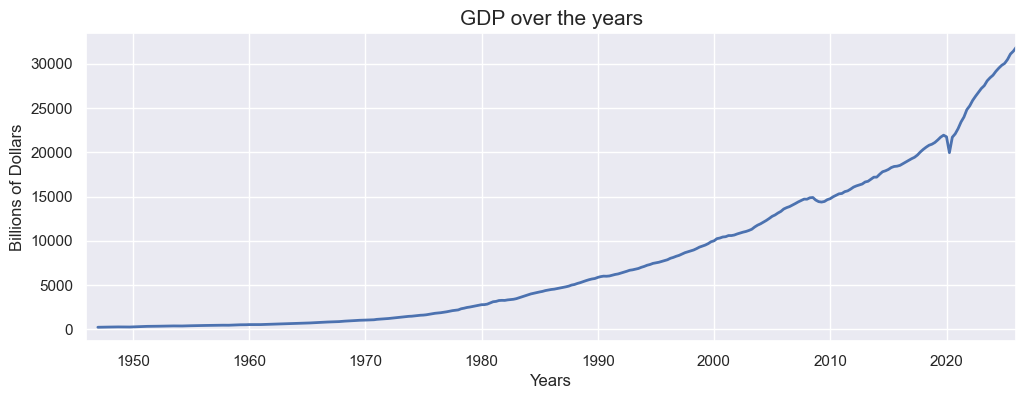

In [7]:
gdp = fred.get_series(series_id="GDP")
gdp.plot(figsize=(12,4), lw=2)
plt.title('GDP over the years', fontdict={'fontsize':'15'})
plt.ylabel("Billions of Dollars")
plt.xlabel("Years")
plt.show()

-----

# Task 3: Work with the unemployment indicator

#### Step1: Search for unemployment 

In [45]:
# We are going to search for unemplyment
unemp_df = fred.search('unemployment state rate', filter=("frequency","Monthly"))
unemp_df.head(5) 

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
UNRATE,UNRATE,2026-07-09,2026-07-09,Unemployment Rate,1948-01-01,2026-06-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-07-02 08:31:40-05:00,96,The unemployment rate represents the number of...
UNRATENSA,UNRATENSA,2026-07-09,2026-07-09,Unemployment Rate,1948-01-01,2026-06-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-07-02 08:31:40-05:00,55,The unemployment rate represents the number of...
U6RATE,U6RATE,2026-07-09,2026-07-09,"Total Unemployed, Plus All Persons Marginally ...",1994-01-01,2026-06-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-07-02 08:31:35-05:00,72,The series comes from the 'Current Population ...
UNEMPLOY,UNEMPLOY,2026-07-09,2026-07-09,Unemployment Level,1948-01-01,2026-06-01,Monthly,M,Thousands of Persons,Thous. of Persons,Seasonally Adjusted,SA,2026-07-02 08:31:34-05:00,69,The series comes from the 'Current Population ...
U6RATENSA,U6RATENSA,2026-07-09,2026-07-09,"Total Unemployed, Plus All Persons Marginally ...",1994-01-01,2026-06-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-07-02 08:31:41-05:00,19,The series comes from the 'Current Population ...


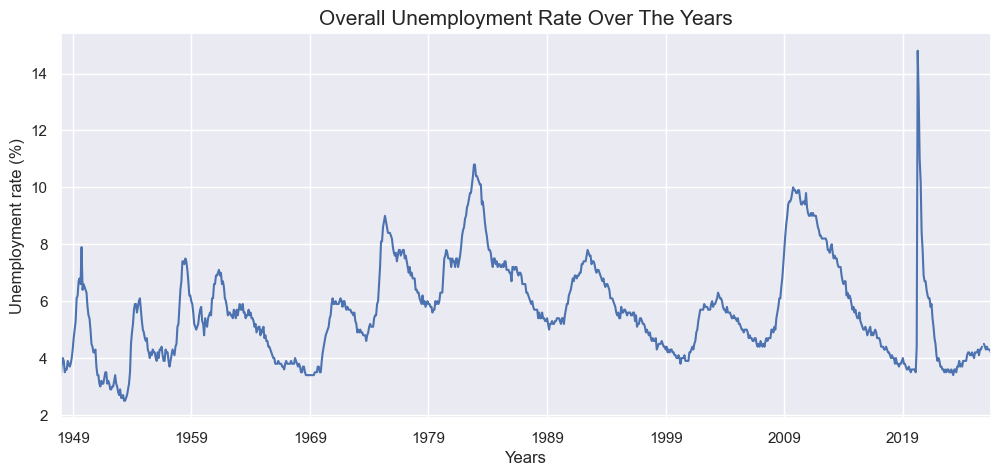

In [46]:
unrate_search = fred.get_series("UNRATE")
unrate_search.plot(figsize=(12,5))
plt.ylabel('Unemployment rate (%)')
plt.xlabel('Years')
plt.title('Overall Unemployment Rate Over The Years', fontdict={'fontsize':'15'})
plt.show()

#### Step 2: filtering for seasonal adjustmeant and units

In [47]:
df_unemp = unemp_df.query("seasonal_adjustment == 'Seasonally Adjusted' and units == 'Percent'")
df_unemp.shape

(71, 15)

#### Step 3: filtering by title name 

In [48]:
df_unemp1 = df_unemp.loc[df_unemp["title"].str.contains("Unemployment Rate")]
df_unemp1.head()

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
UNRATE,UNRATE,2026-07-09,2026-07-09,Unemployment Rate,1948-01-01,2026-06-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-07-02 08:31:40-05:00,96,The unemployment rate represents the number of...
LNS14000006,LNS14000006,2026-07-09,2026-07-09,Unemployment Rate - Black or African American,1972-01-01,2026-06-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-07-02 08:33:06-05:00,65,The series comes from the 'Current Population ...
LNS14024887,LNS14024887,2026-07-09,2026-07-09,Unemployment Rate - 16-24 Yrs.,1948-01-01,2026-06-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-07-02 08:33:10-05:00,65,The series comes from the 'Current Population ...
CAUR,CAUR,2026-07-09,2026-07-09,Unemployment Rate in California,1976-01-01,2026-05-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-06-24 17:56:07-05:00,61,NaN
ALUR,ALUR,2026-07-09,2026-07-09,Unemployment Rate in Alabama,1976-01-01,2026-05-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-06-24 17:56:05-05:00,45,NaN


#### Step 4: Pulling the data from the differents IDs prestend within the dataframe, concatenating them and plotting a line chart.

In [49]:
results_all = []
for i in df_unemp1.index:
    results = fred.get_series(i)
    results = results.to_frame(name=i)
    results_all.append(results)


In [50]:
unemp_results= pd.concat(results_all, axis=1).drop(columns = ["LASMT534266000000003","M0892AUSM156SNBR","M0892BUSM156SNBR","LNS14000036","LNS14000031","LNS14000006","LNS14024887","LNS14027662","LNS14000024","LNS14027660","LNS14027659","LNS14000003","LNS14000009","LNS14000002","LNS14000012","LNS14000001","LNS14000060","LNS14000032"])
unemp_results.tail()

C:\Users\leona\AppData\Local\Temp\ipykernel_8156\1848077831.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  unemp_results= pd.concat(results_all, axis=1).drop(columns = ["LASMT534266000000003","M0892AUSM156SNBR","M0892BUSM156SNBR","LNS14000036","LNS14000031","LNS14000006","LNS14024887","LNS14027662","LNS14000024","LNS14027660","LNS14027659","LNS14000003","LNS14000009","LNS14000002","LNS14000012","LNS14000001","LNS14000060","LNS14000032"])


,UNRATE,CAUR,ALUR,TXUR,FLUR,GAUR,NYUR,LAUR,MSUR,MOUR,MIUR,MAUR,ILUR,OHUR,VAUR,NCUR,NJUR,PAUR,WIUR,DCUR,U2RATE,ORUR,MNUR,COUR,AZUR,TNUR,WAUR,MDUR,KYUR,PRUR,ARUR,NVUR,WVUR,UTUR,INUR,OKUR,NMUR,IAUR,CTUR,AKUR,KSUR,SCUR,HIUR
2026-02-01,4.4,5.4,2.7,4.3,4.6,3.6,4.6,4.3,3.7,3.9,5.0,4.8,5.0,4.2,3.8,3.8,5.1,4.2,3.4,6.5,2.1,5.2,4.5,3.9,4.6,3.6,5.1,4.3,4.2,5.6,4.4,5.3,4.7,3.8,3.3,3.9,4.7,3.4,4.7,4.7,3.9,5.0,2.3
2026-03-01,4.3,5.3,2.7,4.3,4.7,3.5,4.6,4.4,3.8,3.9,5.0,4.7,5.1,4.1,3.8,3.7,4.9,4.2,3.5,6.3,2.0,5.2,4.5,3.9,4.7,3.6,5.1,4.3,4.2,5.6,4.3,5.3,4.5,3.8,3.3,3.9,4.8,3.3,4.8,4.7,3.9,4.9,2.4
2026-04-01,4.3,5.3,2.8,4.3,4.8,3.5,4.6,4.4,3.8,3.8,5.0,4.7,5.1,3.9,3.8,3.7,4.8,4.2,3.5,6.2,2.1,5.2,4.5,3.9,4.7,3.6,5.2,4.4,4.3,5.6,4.3,5.3,4.4,3.8,3.3,4.0,4.9,3.3,5.0,4.6,3.9,4.8,2.4
2026-05-01,4.3,5.3,3.0,4.3,4.8,3.4,4.6,4.5,3.8,3.8,5.1,4.5,5.1,3.7,3.8,3.7,4.7,4.2,3.4,6.1,2.0,5.2,4.4,3.9,4.8,3.6,5.2,4.4,4.5,5.6,4.2,5.2,4.3,3.7,3.3,4.1,4.9,3.2,5.1,4.6,3.8,4.6,2.5
2026-06-01,4.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


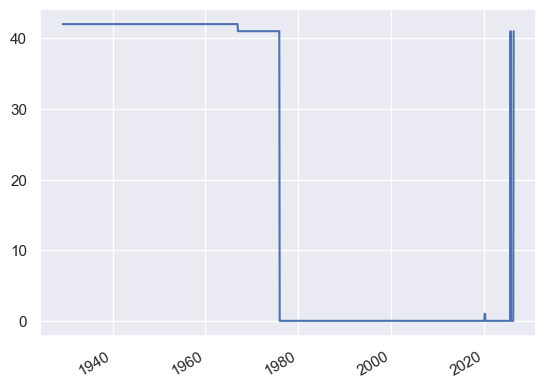

In [51]:
# Dropping UNRATE column
unemp_results = unemp_results.drop("UNRATE",axis=1)
# Checking for null values
unemp_results.isna().sum(axis=1).plot() 
# dropping null
unemp_results = unemp_results.dropna()
uemp_states = unemp_results.copy()

In [52]:
px.line(uemp_states)

#### Step 5: Changing the columns names. replacing the IDs for the state's names.

In [53]:
df_unemp2 = df_unemp1.drop(index=["LASMT534266000000003","M0892AUSM156SNBR","M0892BUSM156SNBR","LNS14000036","LNS14000031","LNS14000006","LNS14024887","LNS14027662","LNS14000024","LNS14027660","LNS14027659","LNS14000003","LNS14000009","LNS14000002","LNS14000012","LNS14000001","LNS14000060","LNS14000032","UNRATE"])
id_to_state = df_unemp2["title"].str.replace("Unemployment Rate in ","").to_dict()
uemp_states.columns = [id_to_state[c] for c in uemp_states.columns]


In [54]:
fig = px.line(uemp_states)
fig

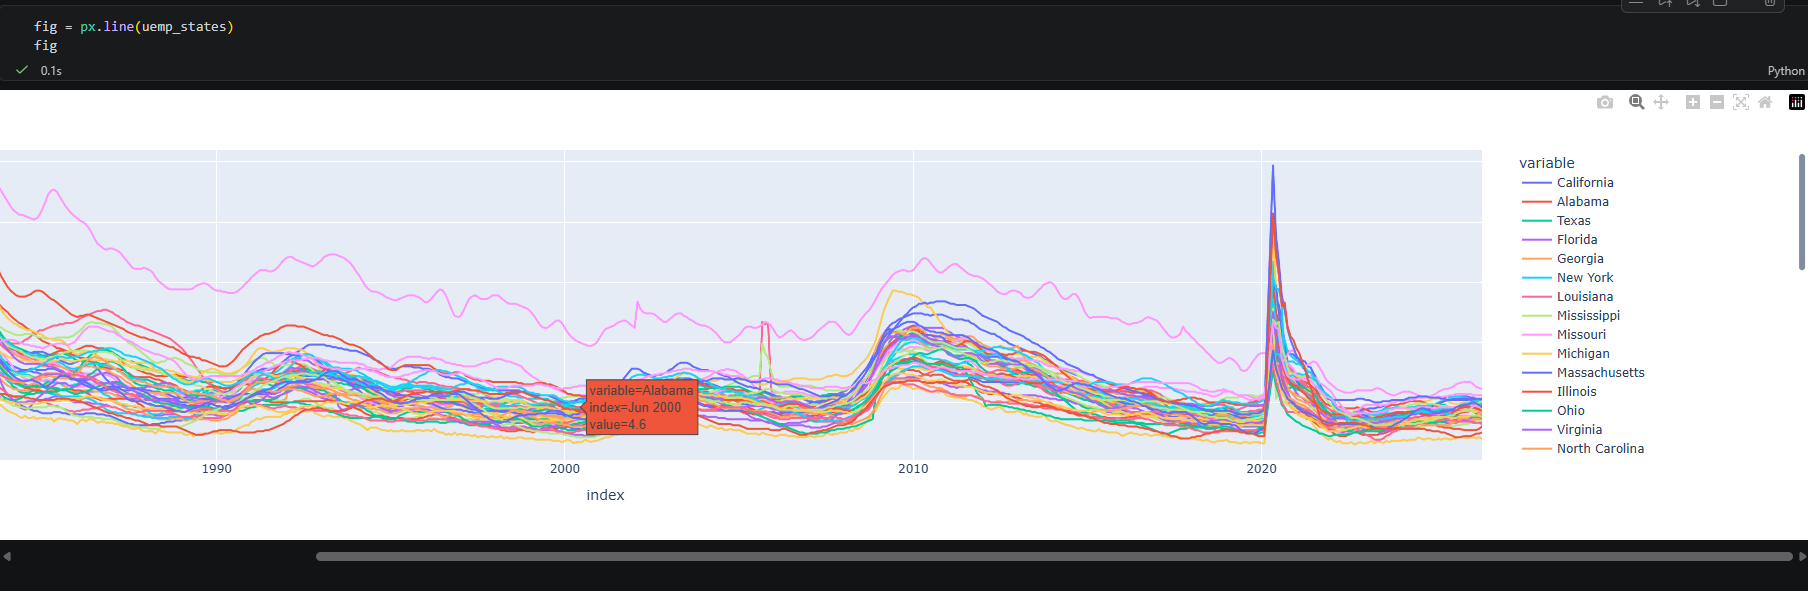

----